In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
main_df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv")

In [5]:
df_encoded = pd.get_dummies(main_df, drop_first=True)

train_df, test_df = train_test_split(df_encoded, random_state=42)

In [6]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

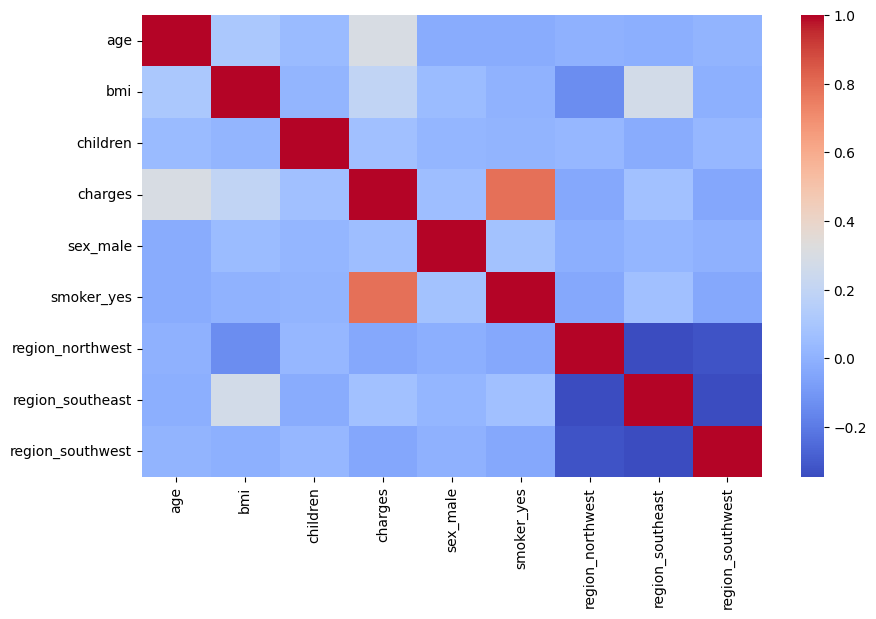

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.show()

In [8]:
train_df, test_df = train_test_split(main_df, random_state=42)
train_df = pd.get_dummies(train_df, drop_first=True)
train_df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
693,24,23.655,0,2352.96845,True,False,True,False,False
1297,28,26.510,2,4340.44090,False,False,False,True,False
634,51,39.700,1,9391.34600,True,False,False,False,True
1022,47,36.080,1,42211.13820,True,True,False,True,False
178,46,28.900,2,8823.27900,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...
1095,18,31.350,4,4561.18850,False,False,False,False,False
1130,39,23.870,5,8582.30230,False,False,False,True,False
1294,58,25.175,0,11931.12525,True,False,False,False,False
860,37,47.600,2,46113.51100,False,True,False,False,True


In [10]:
train_df.isna().sum()
X_train = train_df.drop(columns=['charges'])
y_train= train_df['charges']

In [11]:
linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
train_preds= linreg_model.predict(X_train)

Text(0, 0.5, 'PREDICTED')

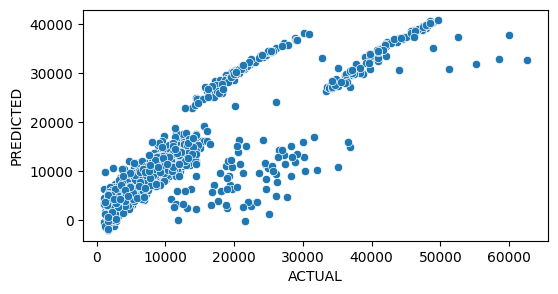

In [13]:
plt.figure(figsize=(6,3))
sns.scatterplot(x= y_train, y= train_preds)
#sns.scatterplot(x=np.linespace(0,5000),y=np.linespace(0,5000))
plt.xlabel("ACTUAL")
plt.ylabel("PREDICTED")

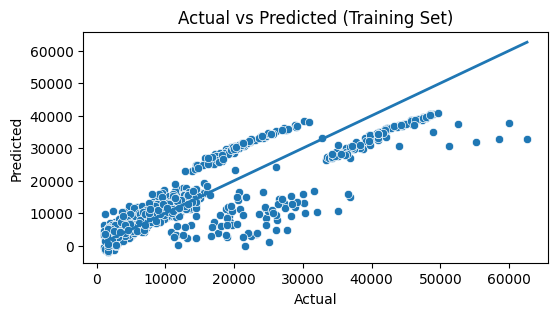

In [14]:
plt.figure(figsize=(6,3))

# Scatter: Actual vs Predicted
sns.scatterplot(x=y_train, y=train_preds)

# Reference line (perfect predictions)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Training Set)")
plt.show()

In [15]:
mae = mean_absolute_error(y_train, train_preds)
mse = mean_squared_error(y_train, train_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_preds)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4183.153367011968
MSE: 37004502.18409475
RMSE: 6083.132596294014
R²: 0.7449555328228536


In [16]:
train_residuals = train_preds - y_train

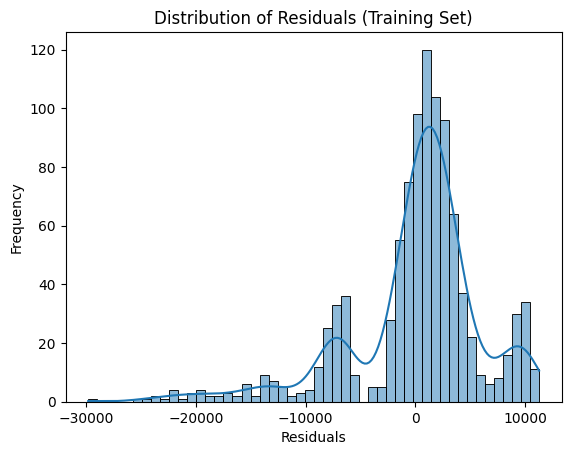

In [17]:
sns.histplot(train_residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals (Training Set)")
plt.show()

In [18]:
temp_residuls = train_residuals.reset_index(drop=True)

In [20]:
train_residuals = train_preds - y_train

Text(0.5, 1.0, 'scatter plot')

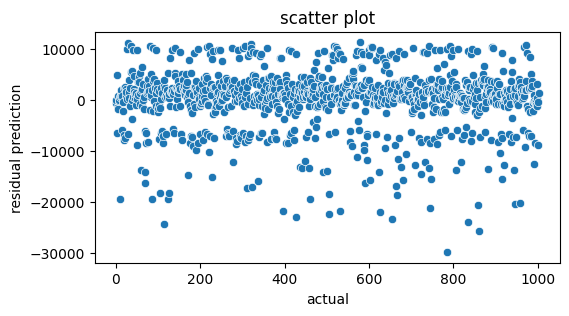

In [21]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=temp_residuls.index, y= temp_residuls)
plt.xlabel("actual")
plt.ylabel("residual prediction")
plt.title("scatter plot")

In [22]:
# Test data
X_test = test_df.drop(columns=['charges'])
y_test = test_df['charges']          

X_test = pd.get_dummies(X_test)
X_test = X_test[X_train.columns]    

test_preds = linreg_model.predict(X_test)

In [23]:
test_mae = mean_absolute_error(y_test, test_preds)
test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_preds)

In [24]:
print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test MAE: 4243.654116653136
Test RMSE: 5926.023602394468
Test R²: 0.7672642952734358


In [25]:
X_train.mean() * linreg_model.coef_

age                 10191.586546
bmi                 10368.056235
children              471.151562
sex_male               23.015901
smoker_yes           4853.302285
region_northwest      -87.105245
region_southeast     -201.769105
region_southwest     -211.850327
dtype: float64